# Predictive Modeling of Cardiovascular Disease Risk

**SIE 433/533 Fundamentals of Data Science for Engineers – Spring 2026**

**Project Members:** Brandon Knox, Justin Larimore, Feruz, Michael Willey

**University of Arizona**

---

This notebook walks through the complete CVD prediction pipeline:
1. Data Acquisition
2. Data Pre-Processing (4C Strategy)
3. Exploratory Data Analysis
4. Model Training (Logistic Regression + Decision Tree)
5. Model Evaluation & Comparison
6. Conclusions

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve,
    confusion_matrix, classification_report, average_precision_score,
)
from imblearn.over_sampling import SMOTE
import warnings

warnings.filterwarnings("ignore")
%matplotlib inline

plt.style.use("seaborn-v0_8-whitegrid")
RANDOM_STATE = 42
COLORS = {"No": "#2196F3", "Yes": "#F44336"}

print("Setup complete.")

Setup complete.


## 2. Data Acquisition

**Source:** 2021 CDC Behavioral Risk Factor Surveillance System (BRFSS) dataset from Kaggle

The dataset contains 308,854 records with 19 variables covering demographic, behavioral, and health-related characteristics. The target variable is a binary Yes/No indication of cardiovascular disease.

In [2]:
df = pd.read_csv("data/raw_cvd_data.csv")
print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print()
print("Column types:")
print(df.dtypes)
print()
print("Missing values:")
print(df.isnull().sum())
df.head()

Dataset shape: 308,854 rows x 19 columns

Column types:
General_Health                      str
Checkup                             str
Exercise                            str
Heart_Disease                       str
Skin_Cancer                         str
Other_Cancer                        str
Depression                          str
Diabetes                            str
Arthritis                           str
Sex                                 str
Age_Category                        str
Height_(cm)                     float64
Weight_(kg)                     float64
BMI                             float64
Smoking_History                     str
Alcohol_Consumption             float64
Fruit_Consumption               float64
Green_Vegetables_Consumption    float64
FriedPotato_Consumption         float64
dtype: object

Missing values:
General_Health                  0
Checkup                         0
Exercise                        0
Heart_Disease                   0
Skin_Cancer      

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,Poor,Within the past 2 years,No,No,No,No,No,No,Yes,Female,70-74,150.0,32.66,14.54,Yes,0.0,30.0,16.0,12.0
1,Very Good,Within the past year,No,Yes,No,No,No,Yes,No,Female,70-74,165.0,77.11,28.29,No,0.0,30.0,0.0,4.0
2,Very Good,Within the past year,Yes,No,No,No,No,Yes,No,Female,60-64,163.0,88.45,33.47,No,4.0,12.0,3.0,16.0
3,Poor,Within the past year,Yes,Yes,No,No,No,Yes,No,Male,75-79,180.0,93.44,28.73,No,0.0,30.0,30.0,8.0
4,Good,Within the past year,No,No,No,No,No,No,No,Male,80+,191.0,88.45,24.37,Yes,0.0,8.0,4.0,0.0


In [3]:
df.describe().round(2)

,Height_(cm),Weight_(kg),BMI,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
count,308854.00,308854.00,308854.00,308854.0,308854.00,308854.00,308854.00
mean,170.62,83.59,28.63,5.1,29.84,15.11,6.30
std,10.66,21.34,6.52,8.2,24.88,14.93,8.58
min,91.00,24.95,12.02,0.0,0.00,0.00,0.00
25%,163.00,68.04,24.21,0.0,12.00,4.00,2.00
50%,170.00,81.65,27.44,1.0,30.00,12.00,4.00
75%,178.00,95.25,31.85,6.0,30.00,20.00,8.00
max,241.00,293.02,99.33,30.0,120.00,128.00,128.00


## 3. Exploratory Data Analysis (EDA)

We perform EDA on the raw data before encoding to keep labels readable.

### 3a. Target Variable Distribution

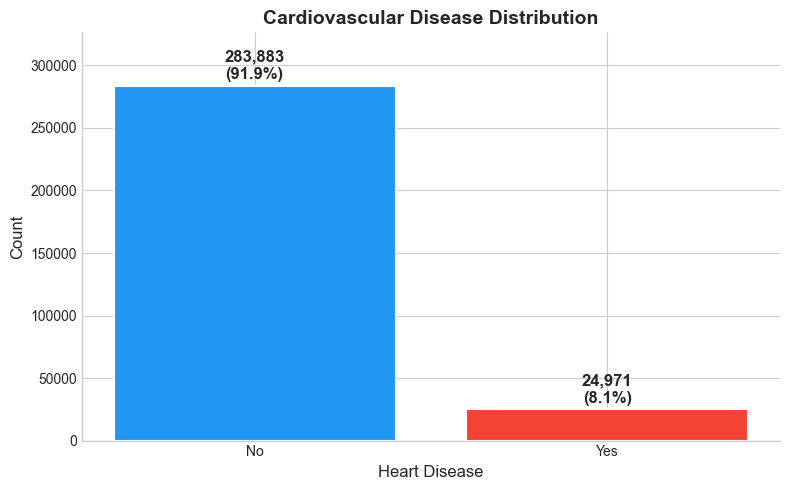

Class imbalance ratio: 0.088


In [4]:
counts = df["Heart_Disease"].value_counts()
pcts = df["Heart_Disease"].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(counts.index, counts.values,
              color=[COLORS.get(k, "#999") for k in counts.index],
              edgecolor="white", linewidth=1.5)

for bar, count, pct in zip(bars, counts.values, pcts.values):
    label = f"{count:,}" + "\n" + f"({pct:.1f}%)"
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + counts.max() * 0.01,
            label, ha="center", va="bottom", fontsize=12, fontweight="bold")

ax.set_title("Cardiovascular Disease Distribution", fontsize=14, fontweight="bold")
ax.set_xlabel("Heart Disease", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_ylim(0, counts.max() * 1.15)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print(f"Class imbalance ratio: {counts.min() / counts.max():.3f}")

### 3b. BMI Distribution by CVD Status

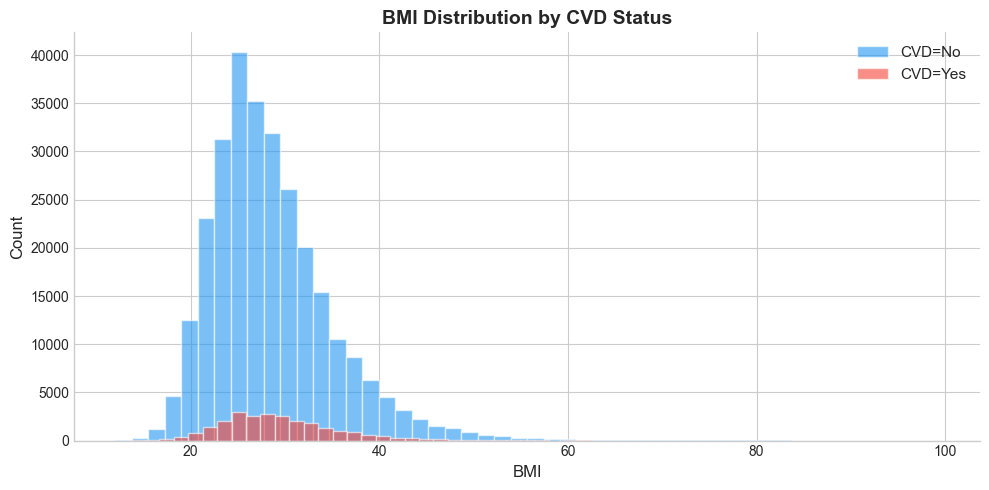

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
for label, color in COLORS.items():
    subset = df[df["Heart_Disease"] == label]["BMI"]
    ax.hist(subset, bins=50, alpha=0.6, label=f"CVD={label}", color=color, edgecolor="white")

ax.set_title("BMI Distribution by CVD Status", fontsize=14, fontweight="bold")
ax.set_xlabel("BMI", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.legend(fontsize=11)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### 3c. Age Category Distribution by CVD Status

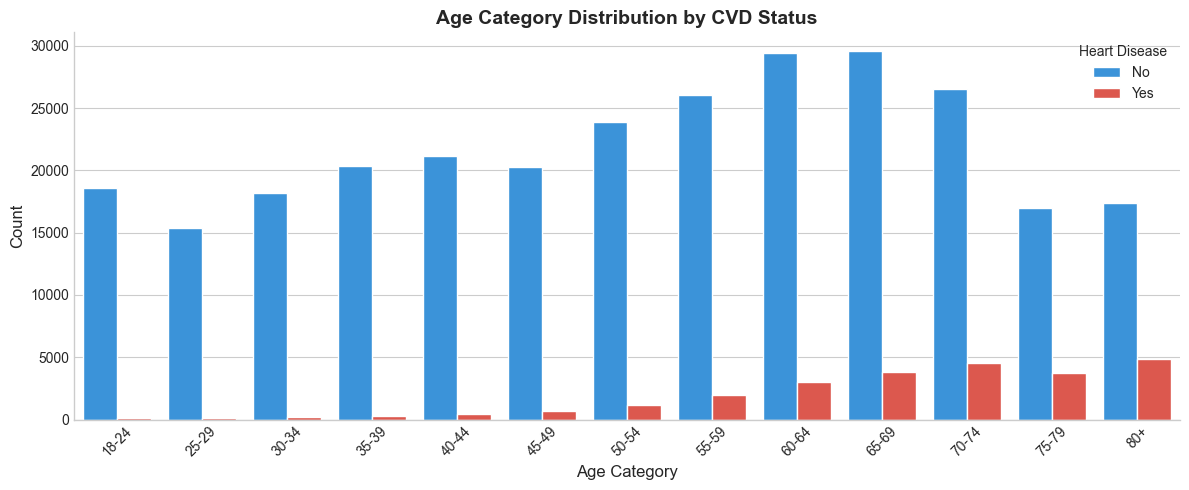

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
age_order = ["18-24", "25-29", "30-34", "35-39", "40-44", "45-49",
             "50-54", "55-59", "60-64", "65-69", "70-74", "75-79", "80+"]
sns.countplot(data=df, x="Age_Category", hue="Heart_Disease",
              order=age_order, palette=COLORS, ax=ax, edgecolor="white")
ax.set_title("Age Category Distribution by CVD Status", fontsize=14, fontweight="bold")
ax.set_xlabel("Age Category", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Heart Disease", fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### 3d. Correlation Heatmap

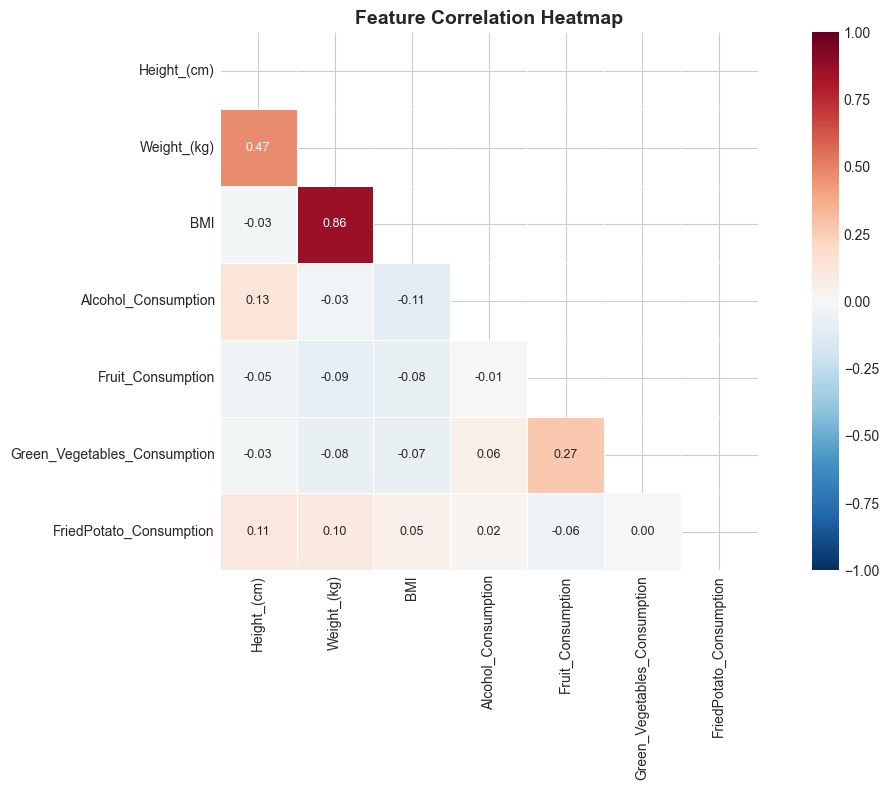

High correlations (|r| > 0.5):
  Weight_(kg) <-> BMI: 0.860


In [7]:
num_df = df.select_dtypes(include=[np.number])
corr = num_df.corr()

fig, ax = plt.subplots(figsize=(12, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            ax=ax, annot_kws={"size": 9})
ax.set_title("Feature Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("High correlations (|r| > 0.5):")
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.5:
            print(f"  {corr.columns[i]} <-> {corr.columns[j]}: {corr.iloc[i, j]:.3f}")

### 3e. Numerical Feature Box Plots

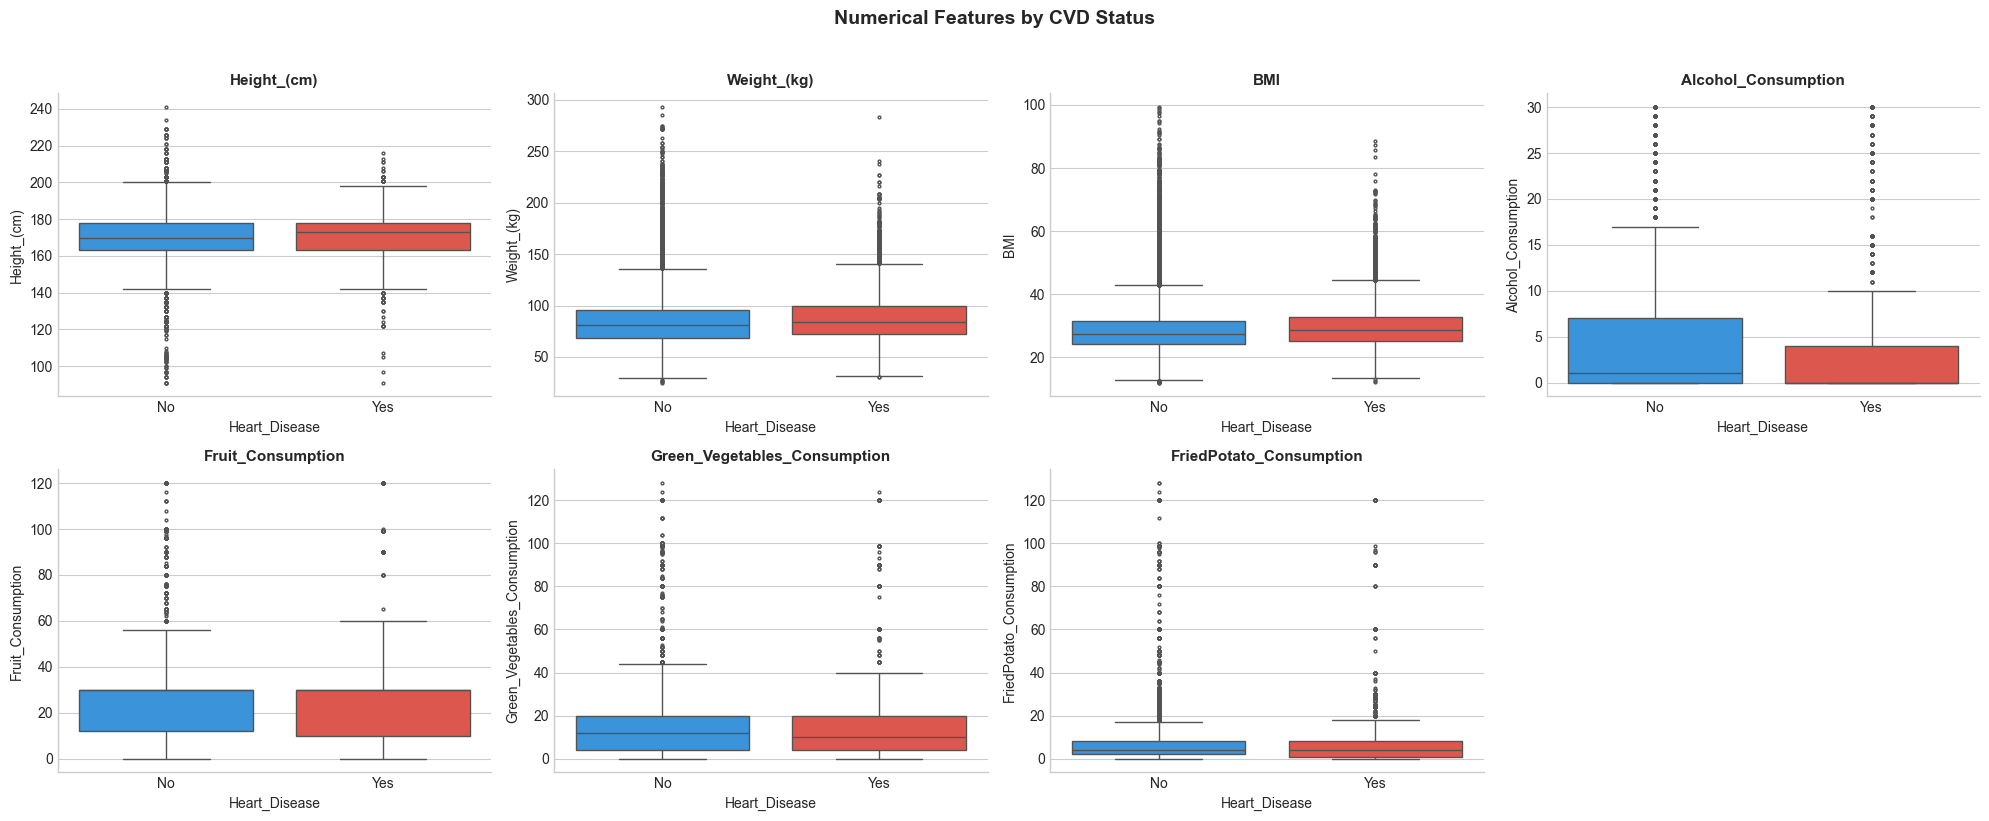

In [8]:
num_cols = ["Height_(cm)", "Weight_(kg)", "BMI", "Alcohol_Consumption",
            "Fruit_Consumption", "Green_Vegetables_Consumption", "FriedPotato_Consumption"]

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x="Heart_Disease", y=col, palette=COLORS, ax=axes[i], fliersize=2)
    axes[i].set_title(col, fontsize=11, fontweight="bold")
    axes[i].spines[["top", "right"]].set_visible(False)
axes[-1].set_visible(False)
fig.suptitle("Numerical Features by CVD Status", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 3f. Categorical Feature Analysis

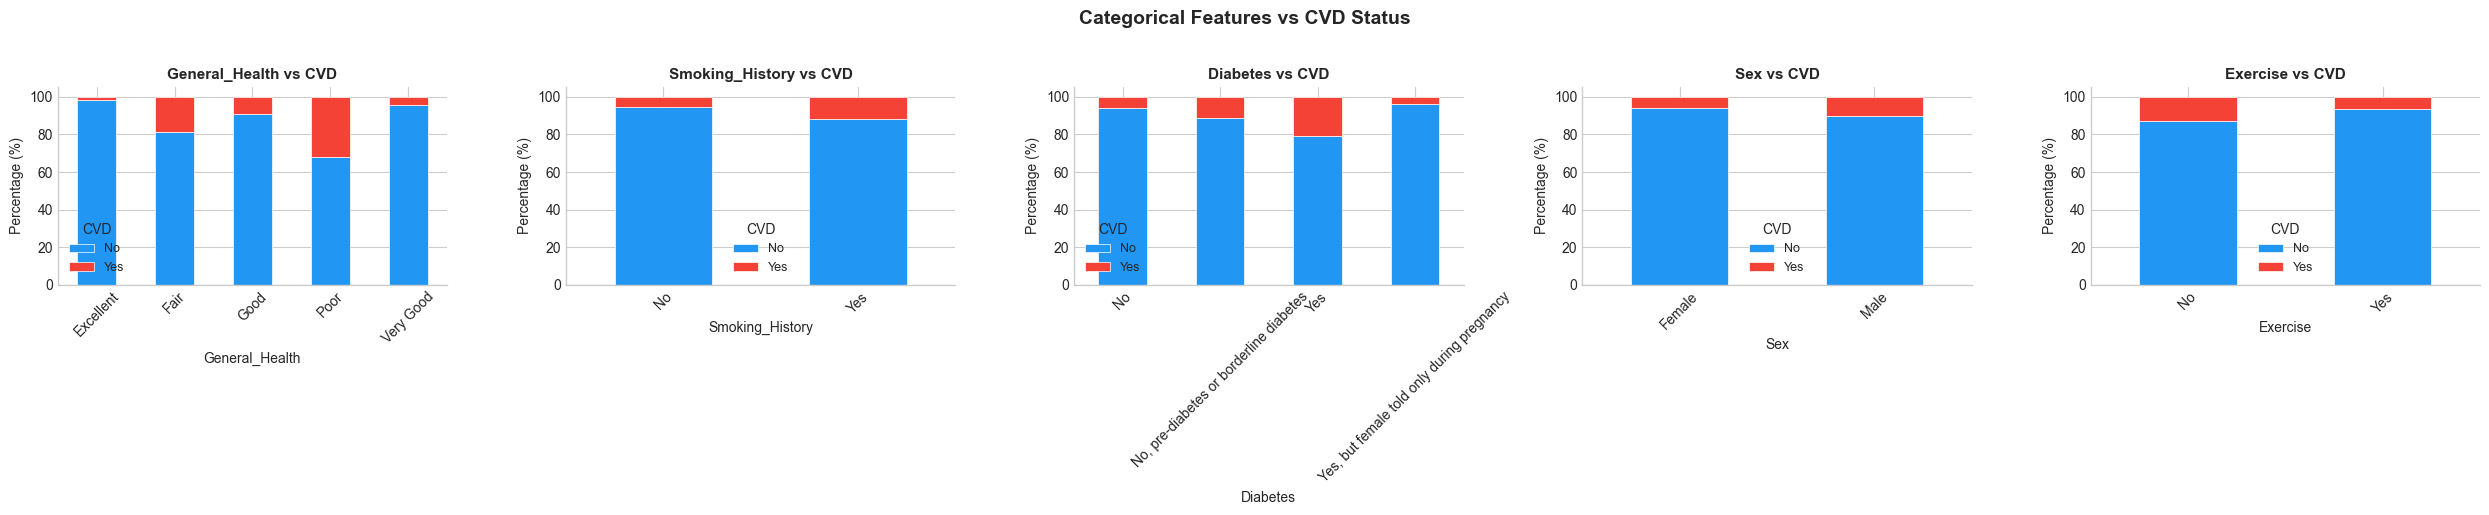

In [9]:
cat_cols = ["General_Health", "Smoking_History", "Diabetes", "Sex", "Exercise"]

fig, axes = plt.subplots(1, 5, figsize=(25, 5))
for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df["Heart_Disease"], normalize="index") * 100
    ct.plot(kind="bar", stacked=True, color=[COLORS["No"], COLORS["Yes"]],
            ax=axes[i], edgecolor="white", linewidth=0.5)
    axes[i].set_title(f"{col} vs CVD", fontsize=11, fontweight="bold")
    axes[i].set_ylabel("Percentage (%)")
    axes[i].legend(title="CVD", labels=["No", "Yes"], fontsize=9)
    axes[i].tick_params(axis="x", rotation=45)
    axes[i].spines[["top", "right"]].set_visible(False)
fig.suptitle("Categorical Features vs CVD Status", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 4. Data Pre-Processing (4C Strategy)

We apply the 4C strategy: **Correcting**, **Completing**, **Converting**, and **Creating**.

**Key design decisions:**
- Outlier lower bounds are floored at 0 (consumption variables cannot be negative)
- All features are scaled with StandardScaler so logistic regression coefficients are comparable
- We do NOT create a Comorbidity_Count feature because it is a linear combination of existing disease columns, which causes multicollinearity and distorts LR coefficients

### 4a. Correcting — Outlier Handling

We use the IQR method to cap extreme outliers. Lower bounds are floored at 0 since consumption and measurement variables cannot be negative.

In [10]:
df_proc = df.copy()

num_cols = ["Height_(cm)", "Weight_(kg)", "BMI", "Alcohol_Consumption",
            "Fruit_Consumption", "Green_Vegetables_Consumption", "FriedPotato_Consumption"]

for col in num_cols:
    Q1 = df_proc[col].quantile(0.25)
    Q3 = df_proc[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = max(Q1 - 1.5 * IQR, 0)  # Floor at 0
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df_proc[col] < lower) | (df_proc[col] > upper)).sum()
    if n_outliers > 0:
        print(f"{col}: {n_outliers:,} outliers capped to [{lower:.1f}, {upper:.1f}]")
        df_proc[col] = df_proc[col].clip(lower, upper)

Height_(cm): 1,055 outliers capped to [140.5, 200.5]
Weight_(kg): 7,326 outliers capped to [27.2, 136.1]
BMI: 9,530 outliers capped to [12.8, 43.3]
Alcohol_Consumption: 36,147 outliers capped to [0.0, 15.0]
Fruit_Consumption: 68,225 outliers capped to [0.0, 57.0]
Green_Vegetables_Consumption: 11,878 outliers capped to [0.0, 44.0]
FriedPotato_Consumption: 19,456 outliers capped to [0.0, 17.0]


### 4b. Completing — Missing Values

In [11]:
total_missing = df_proc.isnull().sum().sum()
print(f"Total missing values: {total_missing}")

if total_missing > 0:
    for col in df_proc.columns:
        n_missing = df_proc[col].isnull().sum()
        if n_missing > 0:
            if df_proc[col].dtype in ["float64", "int64"]:
                df_proc[col].fillna(df_proc[col].median(), inplace=True)
            else:
                df_proc[col].fillna(df_proc[col].mode()[0], inplace=True)
    print(f"After imputation: {df_proc.isnull().sum().sum()} missing")
else:
    print("No missing values found — data is complete.")

Total missing values: 0
No missing values found — data is complete.


### 4c. Converting — Encoding Categorical Variables

- **Binary encoding** for Yes/No columns (0/1)
- **Ordinal encoding** for ordered categories (General_Health, Age_Category, etc.)
- **Label encoding** for Sex (Female=0, Male=1)

In [12]:
# Target variable
df_proc["Heart_Disease"] = df_proc["Heart_Disease"].map({"No": 0, "Yes": 1})

# Binary columns
binary_cols = ["Exercise", "Skin_Cancer", "Other_Cancer", "Depression", "Arthritis", "Smoking_History"]
for col in binary_cols:
    df_proc[col] = df_proc[col].map({"No": 0, "Yes": 1})

# Sex
df_proc["Sex"] = df_proc["Sex"].map({"Female": 0, "Male": 1})

# Ordinal: General_Health
df_proc["General_Health"] = df_proc["General_Health"].map({
    "Poor": 0, "Fair": 1, "Good": 2, "Very Good": 3, "Excellent": 4
})

# Ordinal: Checkup
df_proc["Checkup"] = df_proc["Checkup"].map({
    "Never": 0, "5 or more years ago": 1, "Within the past 5 years": 2,
    "Within the past 2 years": 3, "Within the past year": 4
})

# Ordinal: Diabetes
df_proc["Diabetes"] = df_proc["Diabetes"].map({
    "No": 0, "No, pre-diabetes or borderline diabetes": 1,
    "Yes, but only during pregnancy (female)": 2,
    "Yes, but female told only during pregnancy": 2,
    "Yes": 3
})

# Ordinal: Age_Category
df_proc["Age_Category"] = df_proc["Age_Category"].map({
    "18-24": 0, "25-29": 1, "30-34": 2, "35-39": 3, "40-44": 4,
    "45-49": 5, "50-54": 6, "55-59": 7, "60-64": 8, "65-69": 9,
    "70-74": 10, "75-79": 11, "80+": 12
})

print("Encoding complete.")
print(f"Remaining nulls: {df_proc.isnull().sum().sum()}")
df_proc.head()

Encoding complete.
Remaining nulls: 0


,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,0,3,0,0,0,0,0,0,1,0,10,150.0,32.66,14.54,1,0.0,30.0,16.0,12.0
1,3,4,0,1,0,0,0,3,0,0,10,165.0,77.11,28.29,0,0.0,30.0,0.0,4.0
2,3,4,1,0,0,0,0,3,0,0,8,163.0,88.45,33.47,0,4.0,12.0,3.0,16.0
3,0,4,1,1,0,0,0,3,0,1,11,180.0,93.44,28.73,0,0.0,30.0,30.0,8.0
4,2,4,0,0,0,0,0,0,0,1,12,191.0,88.45,24.37,1,0.0,8.0,4.0,0.0


### 4d. Creating — Feature Engineering

In [13]:
# BMI Category
df_proc["BMI_Category"] = pd.cut(
    df_proc["BMI"], bins=[0, 18.5, 25, 30, 100],
    labels=[0, 1, 2, 3]  # Underweight, Normal, Overweight, Obese
).astype(float).fillna(1).astype(int)

print("New feature created:")
print(f"  BMI_Category distribution: {df_proc['BMI_Category'].value_counts().sort_index().to_dict()}")

New feature created:
  BMI_Category distribution: {0: 4544, 1: 90122, 2: 109644, 3: 104544}


### 4e. Train/Test Split & Scaling

We scale **all** features with StandardScaler (not just numerical ones). This is critical for logistic regression — coefficients are only comparable when all features are on the same scale. A binary feature (0-1) would otherwise get an inflated coefficient compared to an ordinal feature (0-12).

In [14]:
TARGET = "Heart_Disease"
X = df_proc.drop(columns=[TARGET])
y = df_proc[TARGET]
feature_names = list(X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

# Scale ALL features for comparable LR coefficients
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_names, index=X_train.index)
X_test = pd.DataFrame(scaler.transform(X_test), columns=feature_names, index=X_test.index)

print(f"Train: {X_train.shape[0]:,} samples")
print(f"Test:  {X_test.shape[0]:,} samples")
print(f"Features: {len(feature_names)}")
print(f"Target distribution (train): {y_train.value_counts(normalize=True).round(4).to_dict()}")

Train: 247,083 samples
Test:  61,771 samples
Features: 19
Target distribution (train): {0: 0.9191, 1: 0.0809}


## 5. Handling Class Imbalance with SMOTE

The dataset is heavily imbalanced (~8% CVD positive). We apply **SMOTE** (Synthetic Minority Over-sampling Technique) to the training data only to avoid data leakage.

In [15]:
print(f"Before SMOTE: {dict(pd.Series(y_train).value_counts())}")

smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"After SMOTE:  {dict(pd.Series(y_train_sm).value_counts())}")

Before SMOTE: {0: np.int64(227106), 1: np.int64(19977)}


After SMOTE:  {0: np.int64(227106), 1: np.int64(227106)}


## 6. Model Training

### 6a. Logistic Regression (Baseline)

Logistic regression is the fundamental algorithm for binary classification. It provides interpretable coefficients showing how each factor increases or decreases CVD risk.

**Note:** We use default `class_weight` (not `'balanced'`) since SMOTE already handles the class imbalance. Using both would double-compensate.

Top 10 features by coefficient magnitude:
  + Age_Category                        +1.1578
  - General_Health                      -0.6892
  + Sex                                 +0.4819
  + Smoking_History                     +0.2143
  + Checkup                             +0.2131
  + Diabetes                            +0.1635
  + BMI_Category                        +0.1360
  + Depression                          +0.1282
  + Arthritis                           +0.1188
  - Alcohol_Consumption                 -0.1188


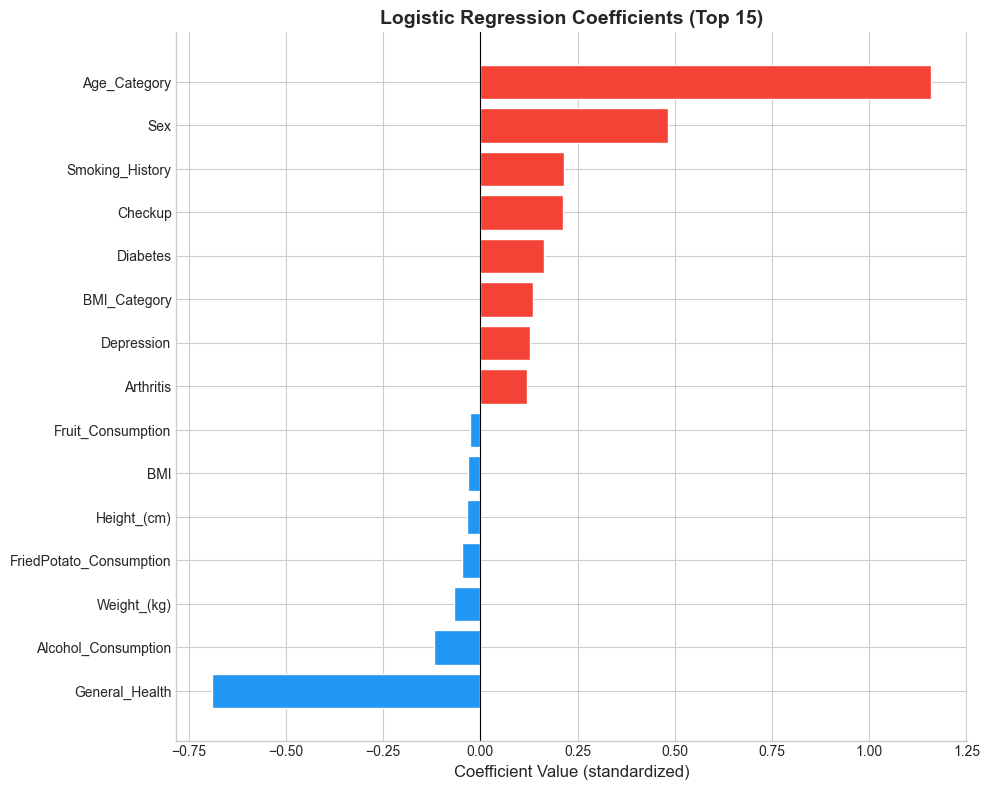

In [16]:
lr_model = LogisticRegression(
    max_iter=1000, solver="lbfgs", random_state=RANDOM_STATE
)
lr_model.fit(X_train_sm, y_train_sm)

# Coefficient analysis
lr_coefs = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": lr_model.coef_[0],
    "Abs_Coefficient": np.abs(lr_model.coef_[0]),
}).sort_values("Abs_Coefficient", ascending=False)

print("Top 10 features by coefficient magnitude:")
for _, row in lr_coefs.head(10).iterrows():
    d = "+" if row["Coefficient"] > 0 else "-"
    print(f"  {d} {row['Feature']:<35} {row['Coefficient']:+.4f}")

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
top = lr_coefs.head(15).sort_values("Coefficient")
colors = ["#F44336" if c > 0 else "#2196F3" for c in top["Coefficient"]]
ax.barh(top["Feature"], top["Coefficient"], color=colors, edgecolor="white")
ax.set_title("Logistic Regression Coefficients (Top 15)", fontsize=14, fontweight="bold")
ax.set_xlabel("Coefficient Value (standardized)", fontsize=12)
ax.axvline(x=0, color="black", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### 6b. Decision Tree (Advanced)

Decision trees capture non-linear relationships that logistic regression might miss. We tune tree depth via cross-validation to prevent overfitting.

  Depth  3: AUC = 0.8444 +/- 0.0011


  Depth  4: AUC = 0.8755 +/- 0.0013


  Depth  5: AUC = 0.8995 +/- 0.0012


  Depth  6: AUC = 0.9165 +/- 0.0009


  Depth  7: AUC = 0.9311 +/- 0.0005


...

  Depth 11: AUC = 0.9645 +/- 0.0010


  Depth 12: AUC = 0.9670 +/- 0.0008


  Depth 13: AUC = 0.9685 +/- 0.0008


  Depth 14: AUC = 0.9689 +/- 0.0006


  Depth 15: AUC = 0.9679 +/- 0.0005

Best depth: 14 (AUC = 0.9689)


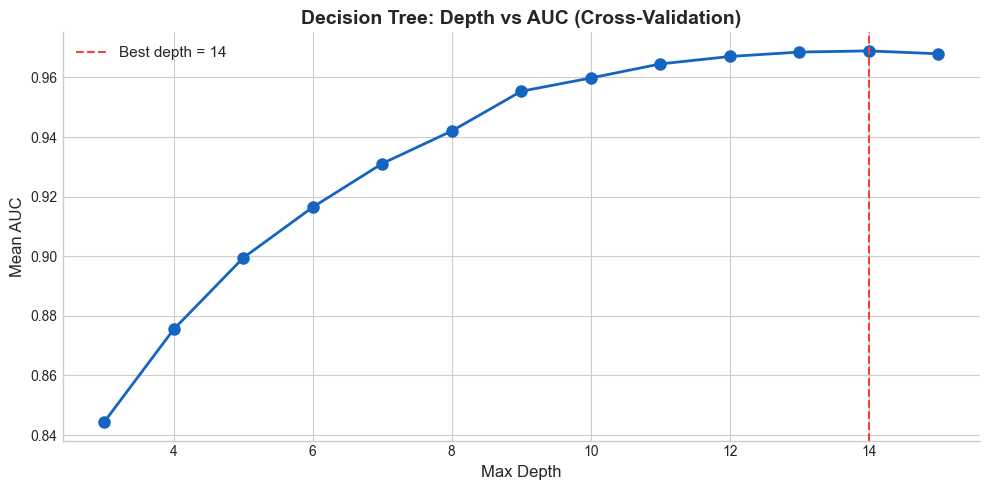

In [17]:
# Tune max_depth
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
depth_range = range(3, 16)
depth_scores = {}

for depth in depth_range:
    dt = DecisionTreeClassifier(max_depth=depth, class_weight="balanced", random_state=RANDOM_STATE)
    scores = cross_val_score(dt, X_train_sm, y_train_sm, cv=cv, scoring="roc_auc")
    depth_scores[depth] = scores.mean()
    print(f"  Depth {depth:>2}: AUC = {scores.mean():.4f} +/- {scores.std():.4f}")

best_depth = max(depth_scores, key=depth_scores.get)
print(f"\nBest depth: {best_depth} (AUC = {depth_scores[best_depth]:.4f})")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(list(depth_scores.keys()), list(depth_scores.values()), "o-", color="#1565C0", linewidth=2, markersize=8)
ax.axvline(x=best_depth, color="#F44336", linestyle="--", label=f"Best depth = {best_depth}")
ax.set_title("Decision Tree: Depth vs AUC (Cross-Validation)", fontsize=14, fontweight="bold")
ax.set_xlabel("Max Depth", fontsize=12)
ax.set_ylabel("Mean AUC", fontsize=12)
ax.legend(fontsize=11)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

Tree depth: 14, leaves: 2080

Top 10 features by importance:
  Age_Category                        0.5954 #############################
  General_Health                      0.2992 ##############
  FriedPotato_Consumption             0.0319 #
  Sex                                 0.0281 #
  Height_(cm)                         0.0080 
  Alcohol_Consumption                 0.0068 
  Fruit_Consumption                   0.0042 
  Green_Vegetables_Consumption        0.0040 
  BMI                                 0.0039 
  Checkup                             0.0037 


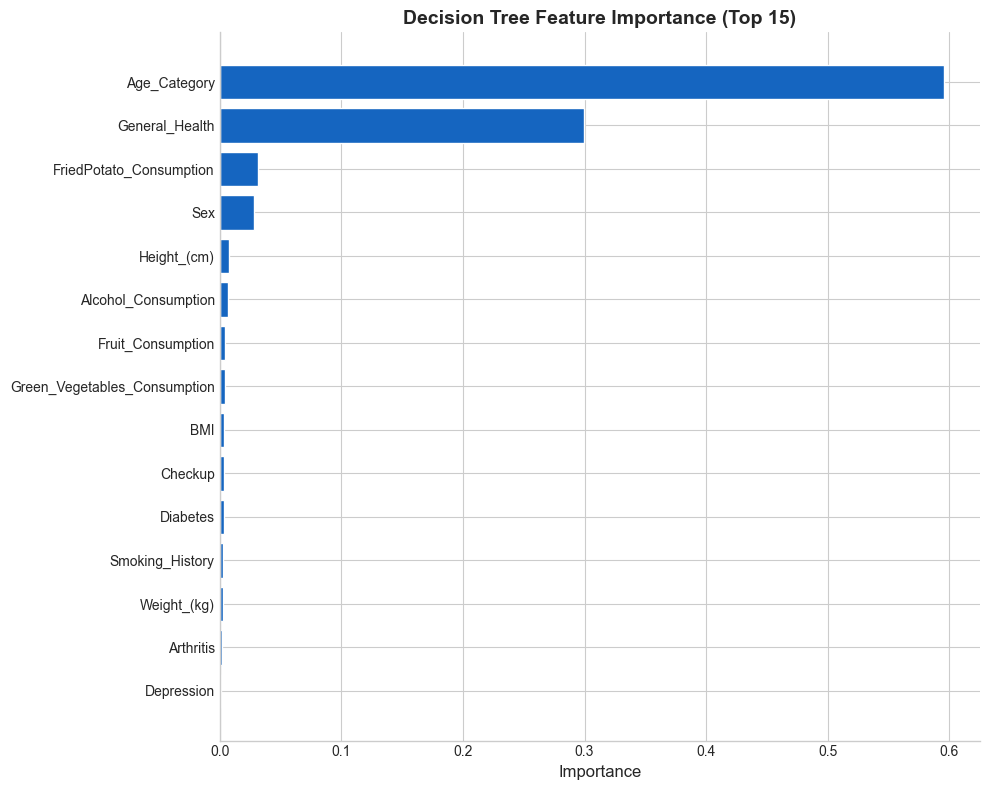

In [18]:
dt_model = DecisionTreeClassifier(
    max_depth=best_depth, class_weight="balanced", random_state=RANDOM_STATE
)
dt_model.fit(X_train_sm, y_train_sm)

print(f"Tree depth: {dt_model.get_depth()}, leaves: {dt_model.get_n_leaves()}")

dt_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": dt_model.feature_importances_,
}).sort_values("Importance", ascending=False)

print("\nTop 10 features by importance:")
for _, row in dt_importance.head(10).iterrows():
    bar = "#" * int(row["Importance"] * 50)
    print(f"  {row['Feature']:<35} {row['Importance']:.4f} {bar}")

fig, ax = plt.subplots(figsize=(10, 8))
top = dt_importance.head(15).sort_values("Importance")
ax.barh(top["Feature"], top["Importance"], color="#1565C0", edgecolor="white")
ax.set_title("Decision Tree Feature Importance (Top 15)", fontsize=14, fontweight="bold")
ax.set_xlabel("Importance", fontsize=12)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

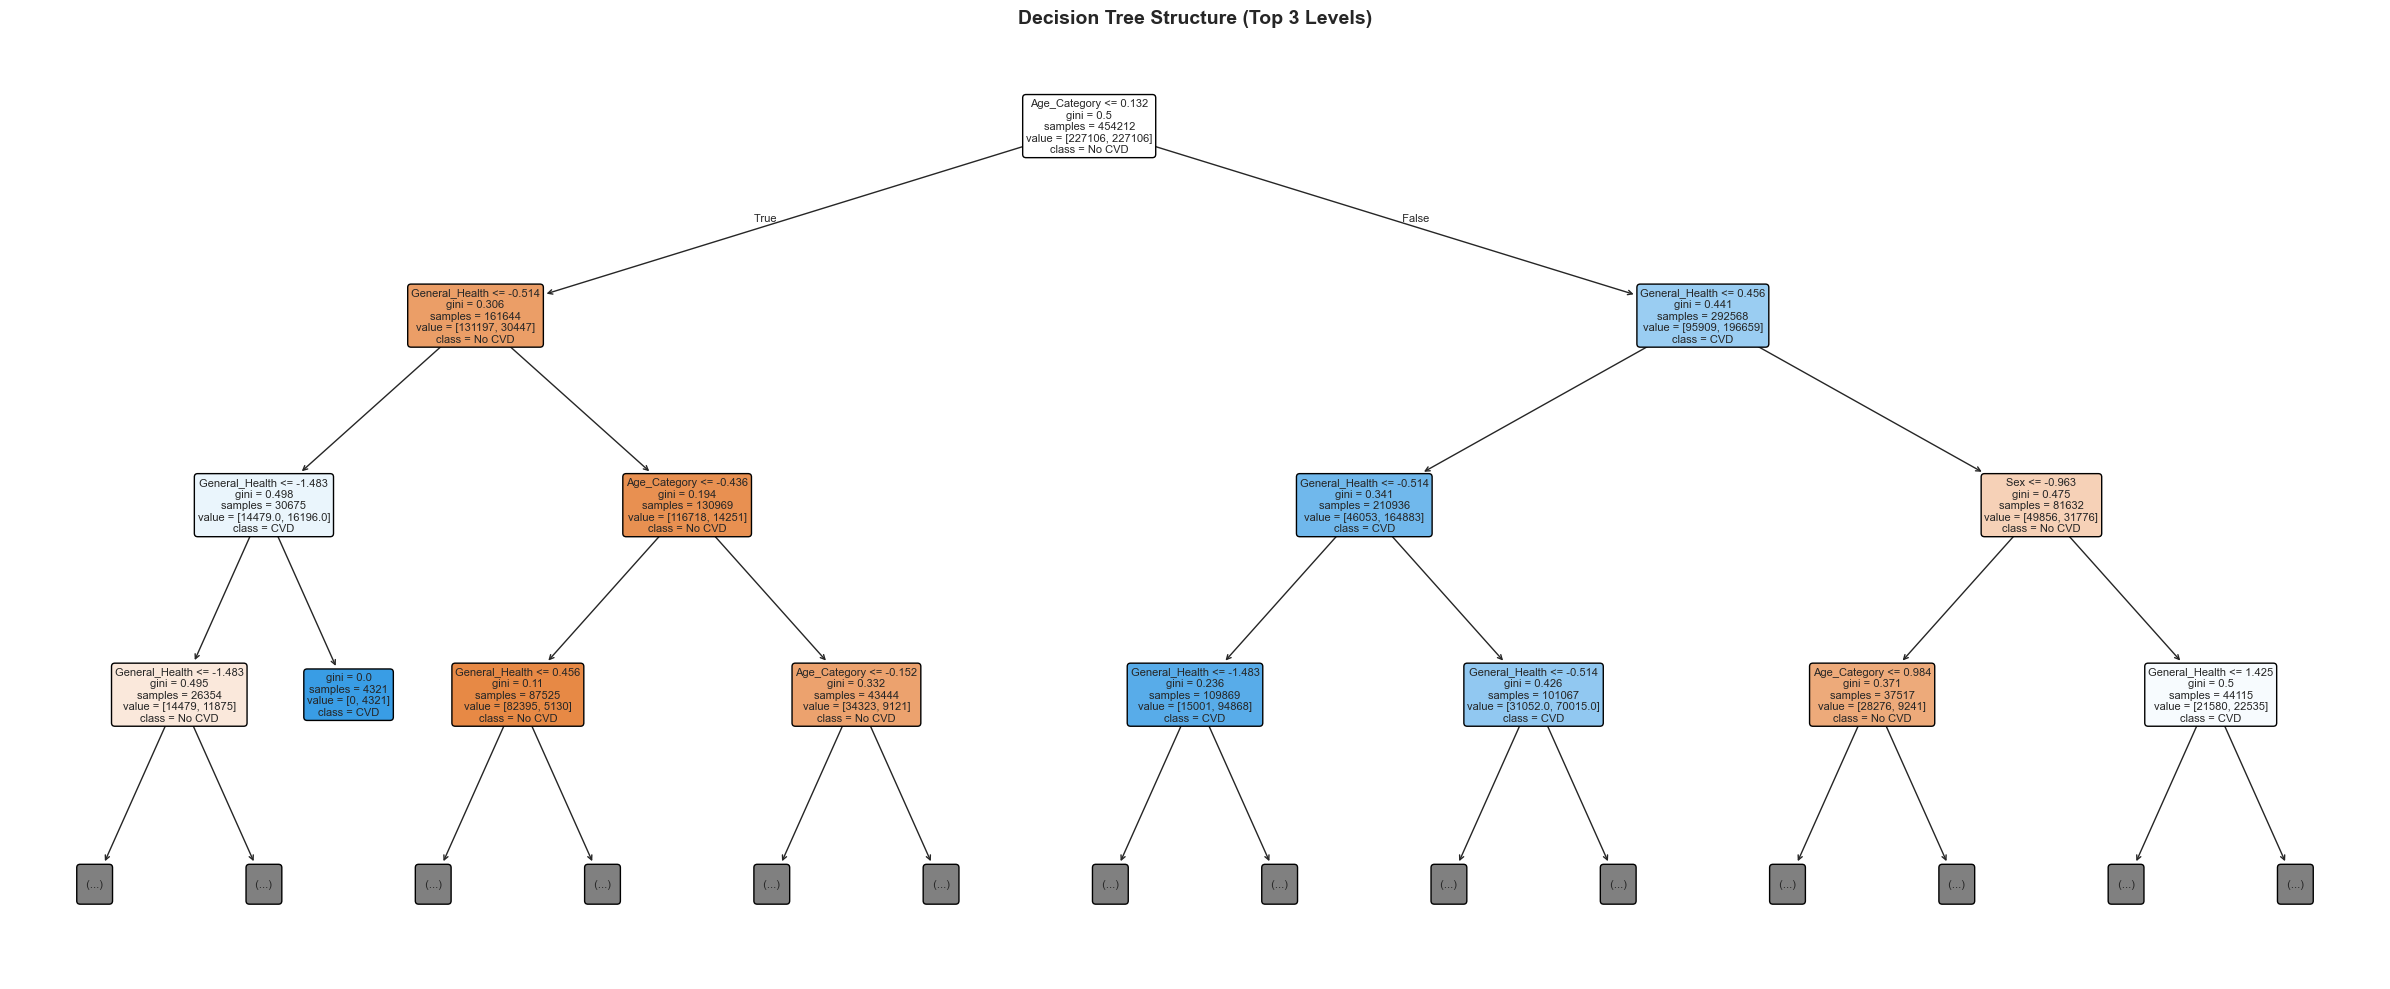

In [19]:
fig, ax = plt.subplots(figsize=(24, 10))
plot_tree(dt_model, max_depth=3, feature_names=feature_names,
          class_names=["No CVD", "CVD"], filled=True, rounded=True, fontsize=8, ax=ax)
ax.set_title("Decision Tree Structure (Top 3 Levels)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 7. Model Evaluation

### 7a. Cross-Validation

In [20]:
models = {"Logistic Regression": lr_model, "Decision Tree": dt_model}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

for name, model in models.items():
    results = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring)
    print(f"\n{name}:")
    for metric in scoring:
        mean = results[f"test_{metric}"].mean()
        std = results[f"test_{metric}"].std()
        print(f"  {metric:<12}: {mean:.4f} +/- {std:.4f}")


Logistic Regression:
  accuracy    : 0.9194 +/- 0.0003
  precision   : 0.5146 +/- 0.0168
  recall      : 0.0626 +/- 0.0049
  f1          : 0.1116 +/- 0.0079
  roc_auc     : 0.8340 +/- 0.0054



Decision Tree:
  accuracy    : 0.7351 +/- 0.0038
  precision   : 0.1887 +/- 0.0009
  recall      : 0.6899 +/- 0.0141
  f1          : 0.2963 +/- 0.0018
  roc_auc     : 0.7285 +/- 0.0085


### 7b. Test Set Results

In [21]:
test_results = {}
predictions = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    test_results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "AUC": roc_auc_score(y_test, y_prob),
    }
    predictions[name] = {"y_pred": y_pred, "y_prob": y_prob}

    print(f"\n{name}:")
    print(classification_report(y_test, y_pred, target_names=["No CVD", "CVD"]))


Logistic Regression:
              precision    recall  f1-score   support

      No CVD       0.98      0.74      0.84     56777
         CVD       0.21      0.79      0.33      4994

    accuracy                           0.74     61771
   macro avg       0.59      0.77      0.59     61771
weighted avg       0.91      0.74      0.80     61771


Decision Tree:
              precision    recall  f1-score   support

      No CVD       0.94      0.95      0.94     56777
         CVD       0.31      0.26      0.28      4994

    accuracy                           0.89     61771
   macro avg       0.62      0.60      0.61     61771
weighted avg       0.89      0.89      0.89     61771



### 7c. Confusion Matrices

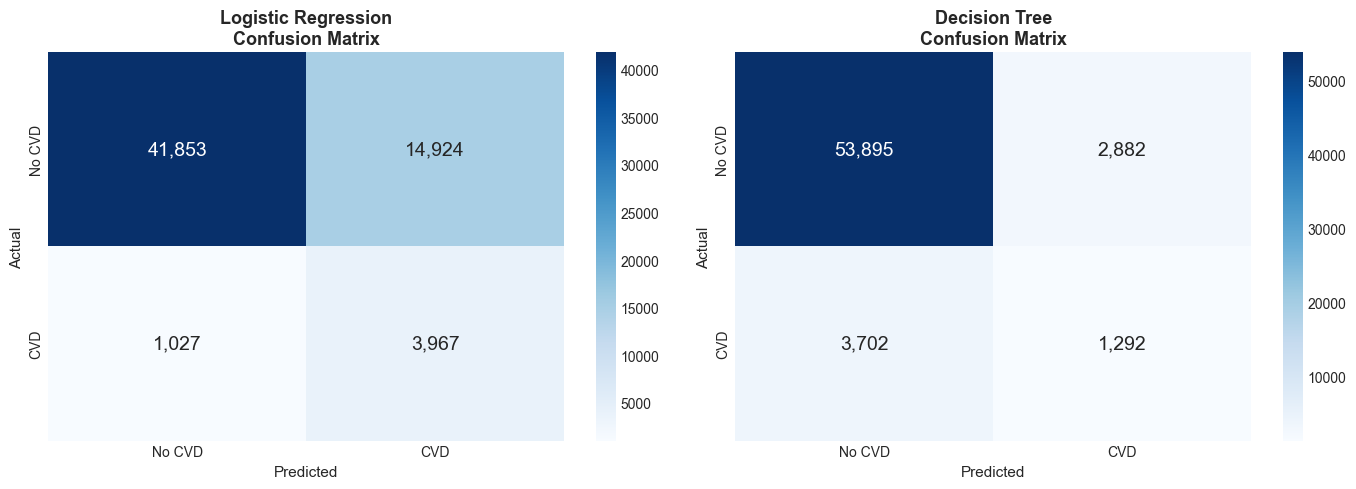

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, (name, preds) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, preds["y_pred"])
    sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues",
                xticklabels=["No CVD", "CVD"], yticklabels=["No CVD", "CVD"],
                ax=axes[i], annot_kws={"size": 14})
    axes[i].set_title(f"{name}\nConfusion Matrix", fontsize=13, fontweight="bold")
    axes[i].set_xlabel("Predicted", fontsize=11)
    axes[i].set_ylabel("Actual", fontsize=11)
plt.tight_layout()
plt.show()

### 7d. ROC Curves

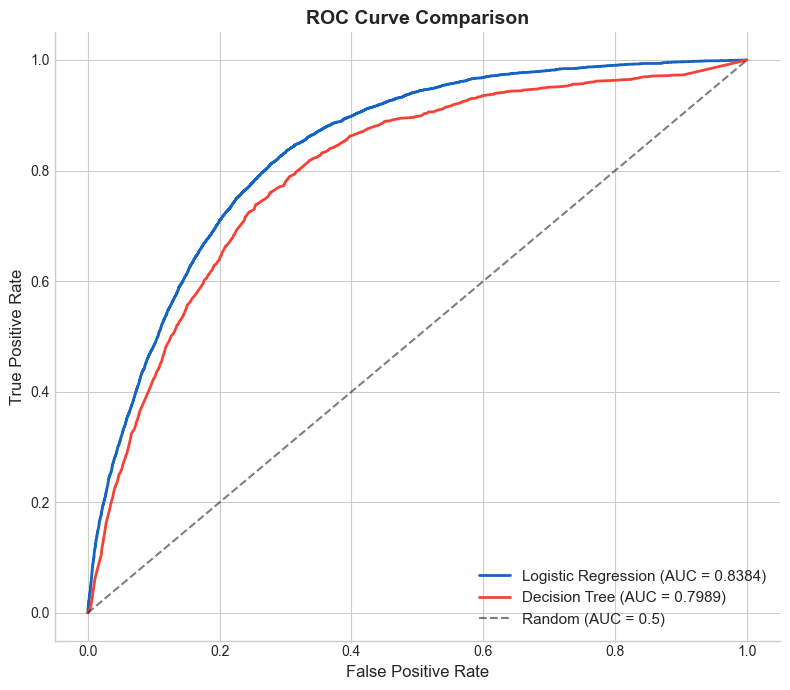

In [23]:
fig, ax = plt.subplots(figsize=(8, 7))
model_colors = {"Logistic Regression": "#1565C0", "Decision Tree": "#F44336"}

for name, preds in predictions.items():
    fpr, tpr, _ = roc_curve(y_test, preds["y_prob"])
    auc = roc_auc_score(y_test, preds["y_prob"])
    ax.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})", color=model_colors[name], linewidth=2)

ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random (AUC = 0.5)")
ax.set_title("ROC Curve Comparison", fontsize=14, fontweight="bold")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.legend(fontsize=11, loc="lower right")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### 7e. Precision-Recall Curves

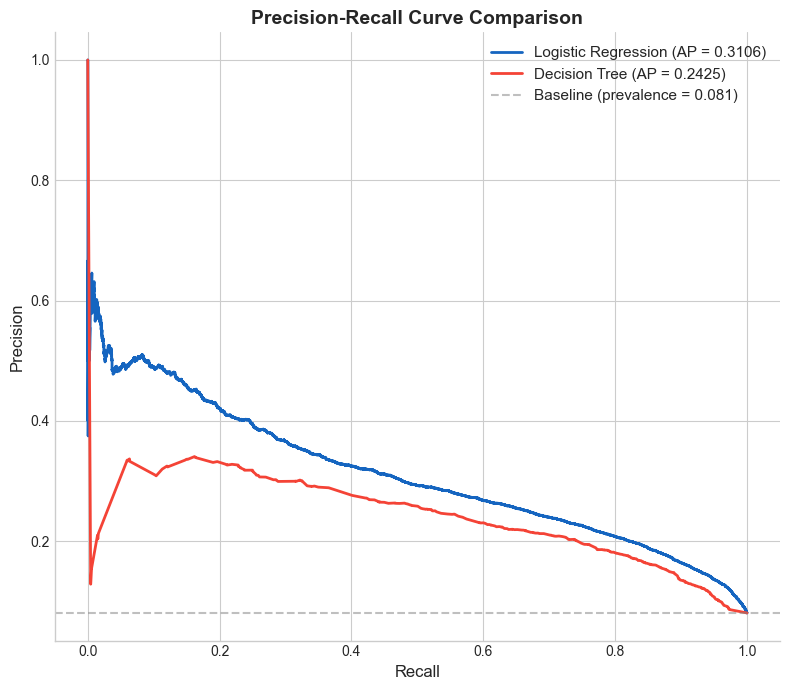

In [24]:
fig, ax = plt.subplots(figsize=(8, 7))

for name, preds in predictions.items():
    prec, rec, _ = precision_recall_curve(y_test, preds["y_prob"])
    ap = average_precision_score(y_test, preds["y_prob"])
    ax.plot(rec, prec, label=f"{name} (AP = {ap:.4f})", color=model_colors[name], linewidth=2)

prevalence = y_test.mean()
ax.axhline(y=prevalence, color="gray", linestyle="--", alpha=0.5,
           label=f"Baseline (prevalence = {prevalence:.3f})")
ax.set_title("Precision-Recall Curve Comparison", fontsize=14, fontweight="bold")
ax.set_xlabel("Recall", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.legend(fontsize=11, loc="upper right")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### 7f. Model Comparison

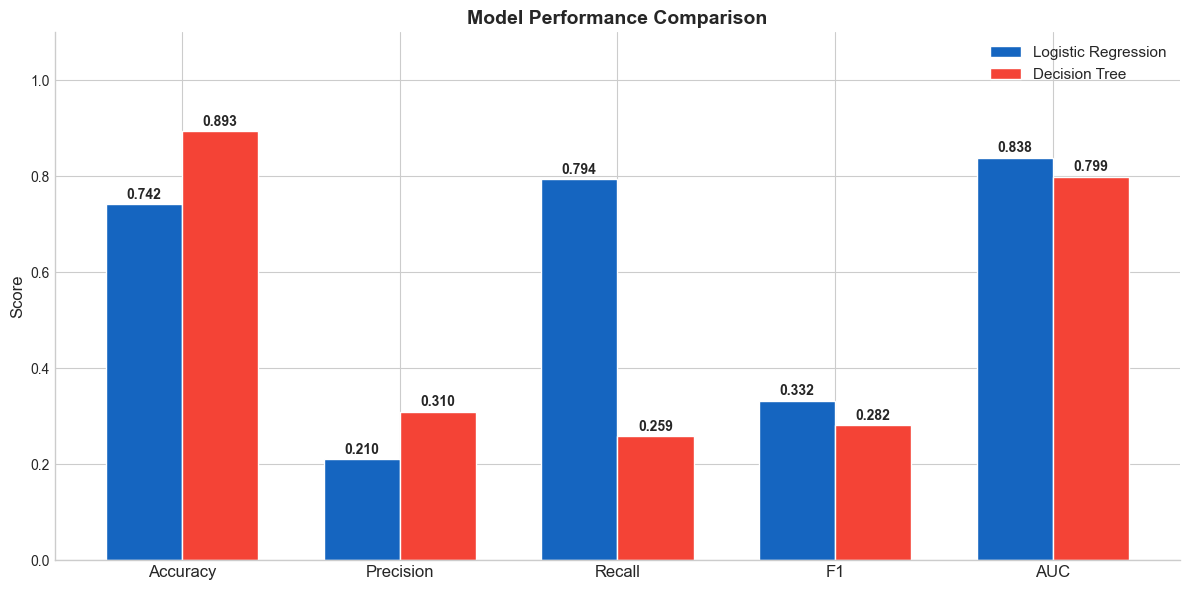


Model Comparison (Test Set):
                     Accuracy  Precision  Recall      F1     AUC
Logistic Regression    0.7418     0.2100  0.7944  0.3322  0.8384
Decision Tree          0.8934     0.3095  0.2587  0.2818  0.7989


In [25]:
metrics = ["Accuracy", "Precision", "Recall", "F1", "AUC"]
comp_df = pd.DataFrame(test_results).T[metrics]

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(metrics))
width = 0.35
colors_list = ["#1565C0", "#F44336"]

for i, (name, row) in enumerate(comp_df.iterrows()):
    bars = ax.bar(x + i * width, row.values, width, label=name,
                  color=colors_list[i], edgecolor="white", linewidth=1)
    for bar, val in zip(bars, row.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_title("Model Performance Comparison", fontsize=14, fontweight="bold")
ax.set_ylabel("Score", fontsize=12)
ax.set_xticks(x + width / 2)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=11)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print("\nModel Comparison (Test Set):")
print(comp_df.round(4).to_string())

### 7g. Feature Importance Comparison

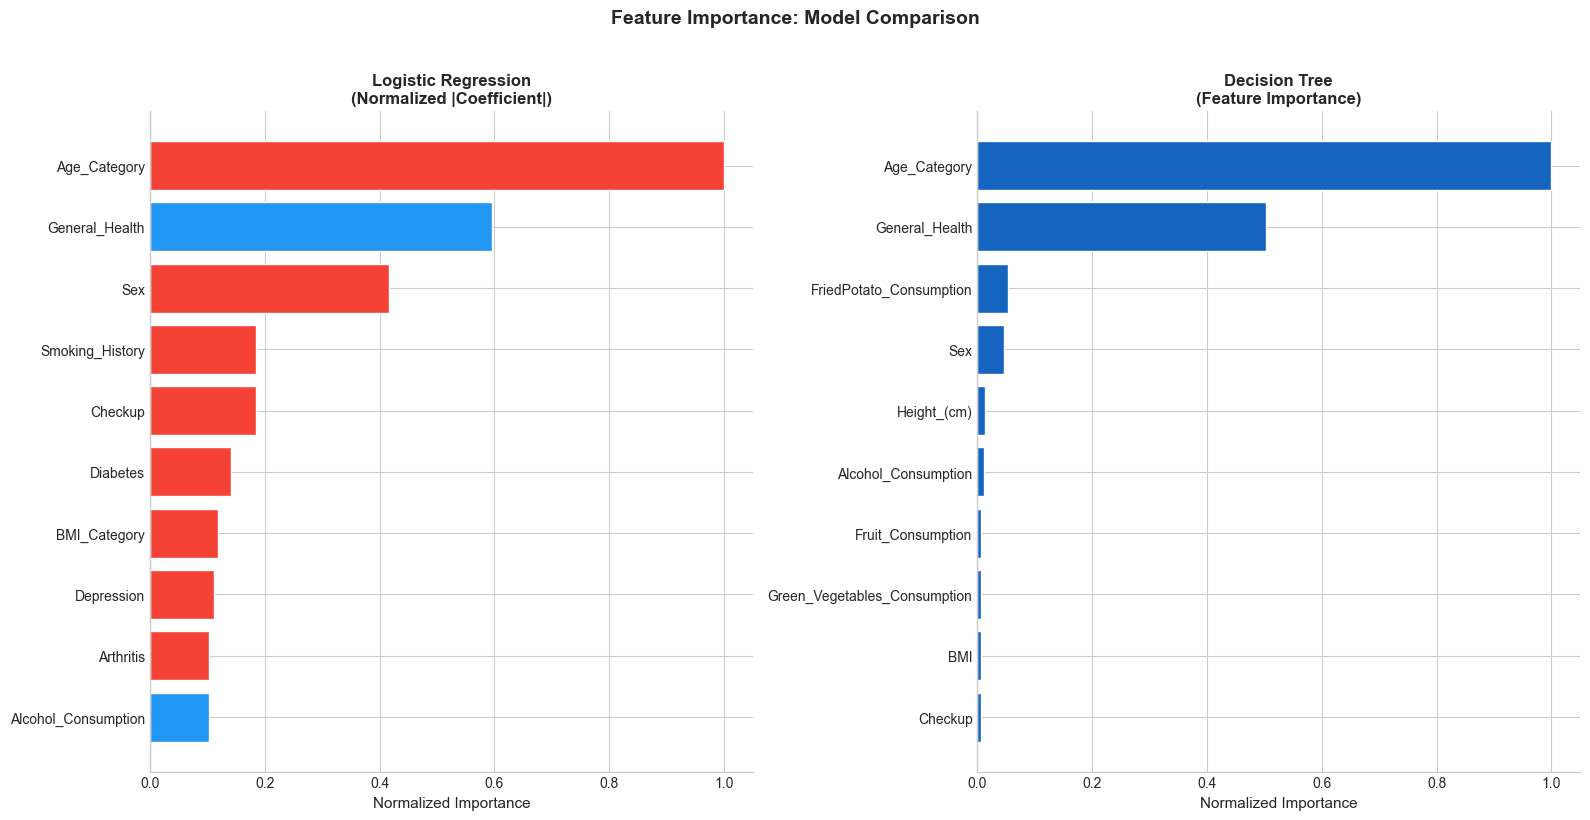

Top 10 features overlap: 5/10
Shared: ['Age_Category', 'Alcohol_Consumption', 'Checkup', 'General_Health', 'Sex']


In [26]:
lr_norm = lr_coefs.copy()
lr_norm["Normalized"] = lr_norm["Abs_Coefficient"] / lr_norm["Abs_Coefficient"].max()
dt_norm = dt_importance.copy()
dt_norm["Normalized"] = dt_norm["Importance"] / dt_norm["Importance"].max()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

top_lr = lr_norm.head(10).sort_values("Normalized")
colors_lr = ["#F44336" if c > 0 else "#2196F3" for c in top_lr["Coefficient"]]
ax1.barh(top_lr["Feature"], top_lr["Normalized"], color=colors_lr, edgecolor="white")
ax1.set_title("Logistic Regression\n(Normalized |Coefficient|)", fontsize=12, fontweight="bold")
ax1.set_xlabel("Normalized Importance", fontsize=11)
ax1.spines[["top", "right"]].set_visible(False)

top_dt = dt_norm.head(10).sort_values("Normalized")
ax2.barh(top_dt["Feature"], top_dt["Normalized"], color="#1565C0", edgecolor="white")
ax2.set_title("Decision Tree\n(Feature Importance)", fontsize=12, fontweight="bold")
ax2.set_xlabel("Normalized Importance", fontsize=11)
ax2.spines[["top", "right"]].set_visible(False)

fig.suptitle("Feature Importance: Model Comparison", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# Overlap
lr_top = set(lr_norm.head(10)["Feature"].values)
dt_top = set(dt_norm.head(10)["Feature"].values)
print(f"Top 10 features overlap: {len(lr_top & dt_top)}/10")
print(f"Shared: {sorted(lr_top & dt_top)}")

## 8. Conclusion

### Summary

We built and compared two supervised classification models for predicting cardiovascular disease risk using the 2021 CDC BRFSS dataset (308,854 records, 19 features).

**Logistic Regression** achieved the higher AUC and significantly better recall, making it the stronger model for this healthcare application where identifying positive cases is critical.

### Key Predictors

Both models identified **Age Category** and **General Health status** as the top two predictors. The initial expectations of age, diabetes, smoking, and BMI as key predictors were confirmed — all appeared in the logistic regression top 10 features.

### Engineering Insights

This model could be integrated into a patient portal or clinical decision support system to flag high-risk individuals for further screening, supporting preventative care and improved resource allocation.

### Limitations

- **Self-reported data**: BRFSS relies on survey responses, introducing potential reporting bias
- **Cross-sectional design**: Cannot establish causal relationships
- **Class imbalance**: Only ~8% positive cases; despite SMOTE, precision remains low
- **Feature limitations**: Restricted to variables available in the BRFSS survey